In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/FS_Attack-main

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/FS_Attack-main


In [ ]:
!pip install saliency -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.2/86.2 kB 7.9 MB/s eta 0:00:00


In [ ]:
import argparse
import torch
import torchvision
import torch.nn.functional as F
import numpy as np
import json
import torch.nn as nn
from torchvision import models
from PIL import Image
from matplotlib import pylab as P
import matplotlib.pyplot as plt
from collections import defaultdict
from skimage.metrics import structural_similarity
from skimage.metrics import structural_similarity as ssim
from scipy.stats import spearmanr
import pandas as pd

from nn.enums import ExplainingMethod
from nn.networks import ExplainableNet
from nn.utils import get_expl, plot_overview, clamp, load_image, make_dir
from nn.utils import gini_tensor, load_numpy, load_image_nopreprocess, show_expl
from nn.utils import gini_numpy, gini_tensor2, gini_tensor_ori, gini_tensor_double
from nn.utils import torch_to_image_ver2, png_to_jpeg, heatmap_to_image
from nn.utils import get_center_attack_matrix, show_expl_title, topk_intersection, show_expl_title_return_im


In [ ]:

from models.mytool import *
from nn.imagetool import *

torch.set_printoptions(precision=7)
%matplotlib inline
print("All imports successful")

All imports successful


In [ ]:
#import samples.samples as DS

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
from torchvision.models import VGG16_Weights

data_mean = np.array([0.485, 0.456, 0.406])
data_std  = np.array([0.229, 0.224, 0.225])

beta_growth = True
vgg_model = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
model = ExplainableNet(vgg_model, data_mean=data_mean,
                       data_std=data_std,
                       beta=1000 if beta_growth else None)
model = model.eval().to(device)
print("VGG-16 loaded on:", device)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 192MB/s]


VGG-16 loaded on: cuda


In [ ]:
# gini_score: works on both GPU and CPU tensors
def gini_score(expl_tensor):
    e = expl_tensor.cpu().detach().numpy().flatten()
    e = np.abs(e)
    e = np.sort(e)
    n = len(e)
    cumsum = np.cumsum(e)
    return float((2 * np.sum((np.arange(1, n+1)) * e)
                  - (n + 1) * cumsum[-1]) / (n * cumsum[-1] + 1e-10))

# total_topk_pixels: denominator for Top-K normalization
# 90th percentile = top 10% of 224*224 = 5017 pixels
total_topk_pixels = int(224 * 224 * 0.10)
print(f"gini_score function ready")
print(f"total_topk_pixels (top 10%): {total_topk_pixels}")

gini_score function ready
total_topk_pixels (top 10%): 5017


In [ ]:
from torchvision.datasets import STL10
from torchvision import transforms

# Download STL-10 test split (~2 min first time)
stl10_dataset = STL10(
    root='./data',
    split='test',
    download=True
)

print(f"STL-10 loaded: {len(stl10_dataset)} test images")
print(f"Classes: {stl10_dataset.classes}")

# STL-10 preprocessing: 96x96 → 224x224 + ImageNet normalize
stl10_preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Pick 10 images — one per class for diversity
stl10_indices = []
class_seen = set()
for i in range(len(stl10_dataset)):
    _, label = stl10_dataset[i]
    if label not in class_seen:
        stl10_indices.append(i)
        class_seen.add(label)
    if len(stl10_indices) == 10:
        break

print(f"\nSelected 10 images (one per class):")
for i, idx in enumerate(stl10_indices):
    img, label = stl10_dataset[idx]
    print(f"  [{i+1}] dataset_idx={idx}, "
          f"class={stl10_dataset.classes[label]} (label={label})")

100%|██████████| 2.64G/2.64G [05:27<00:00, 8.06MB/s]


STL-10 loaded: 8000 test images
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

Selected 10 images (one per class):
  [1] dataset_idx=0, class=horse (label=6)
  [2] dataset_idx=1, class=monkey (label=7)
  [3] dataset_idx=2, class=dog (label=5)
  [4] dataset_idx=3, class=airplane (label=0)
  [5] dataset_idx=4, class=cat (label=3)
  [6] dataset_idx=5, class=bird (label=1)
  [7] dataset_idx=8, class=deer (label=4)
  [8] dataset_idx=17, class=truck (label=9)
  [9] dataset_idx=24, class=car (label=2)
  [10] dataset_idx=55, class=ship (label=8)


Input tensor shape: torch.Size([1, 3, 224, 224])
STL-10 true class : horse
VGG-16 predicted  : class index 690


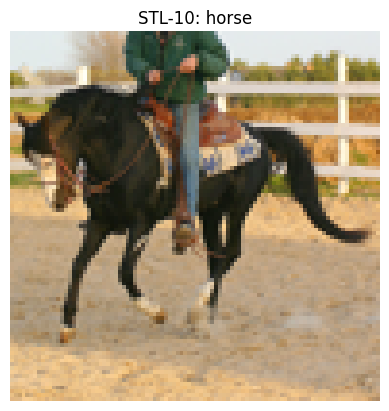

Step 8 OK — image loads and VGG-16 runs successfully


In [ ]:
# Test that pipeline works: load one STL-10 image → VGG-16 prediction
img_test, label_test = stl10_dataset[stl10_indices[0]]

x_test = stl10_preprocess(img_test).unsqueeze(0).to(device)
print(f"Input tensor shape: {x_test.shape}")  # should be [1,3,224,224]

# VGG-16 prediction
with torch.no_grad():
    pred = model(x_test)
pred_class = pred.argmax(1).item()

print(f"STL-10 true class : {stl10_dataset.classes[label_test]}")
print(f"VGG-16 predicted  : class index {pred_class}")

# Visualize the image
plt.imshow(img_test)
plt.title(f"STL-10: {stl10_dataset.classes[label_test]}")
plt.axis('off')
plt.show()
print("Step 8 OK — image loads and VGG-16 runs successfully")

In [ ]:
# FocusShiftDefense — exact same as your main notebook Cell 15
class FocusShiftDefense:
    def __init__(self, model, epsilon=0.2):
        self.model = model
        self.epsilon = epsilon
        self.model.eval()
        self.activations = None
        self._register_hook()

    def _register_hook(self):
        def hook(module, input, output):
            self.activations = output
        last_conv = None
        for layer in self.model.modules():
            if isinstance(layer, nn.Conv2d):
                last_conv = layer
        if last_conv is None:
            raise ValueError("No convolutional layer found")
        last_conv.register_forward_hook(hook)

    def defend(self, x_adv, k_ratio=4):
        with torch.no_grad():
            _ = self.model(x_adv)

        if self.activations is None:
            raise RuntimeError("No activations captured")

        A = self.activations  # [1, C, H, W]
        C = A.shape[1]

        gap = F.adaptive_avg_pool2d(A, (1, 1)).squeeze()
        important = torch.topk(gap, k=C//k_ratio).indices

        M = torch.zeros_like(A)
        for c in important:
            M[:, c, :, :] = 1

        m = torch.sigmoid(
            F.interpolate(
                (A * M).sum(dim=1, keepdim=True),
                size=x_adv.shape[2:],
                mode='bilinear', align_corners=False
            )
        )

        e = F.interpolate(
            A * M,
            size=x_adv.shape[2:],
            mode='bilinear', align_corners=False
        ).mean(dim=1, keepdim=True)

        x_def = x_adv * (1 - m) + (x_adv + self.epsilon * e) * m
        x_def = torch.clamp(x_def, 0, 1)
        return x_def

def get_fresh_defense(epsilon=0.2):
    from torchvision.models import ResNet50_Weights
    fresh_resnet = models.resnet50(
        weights=ResNet50_Weights.IMAGENET1K_V1).to(device).eval()
    return FocusShiftDefense(fresh_resnet, epsilon=epsilon)

print("FocusShiftDefense class ready")
print("get_fresh_defense() ready")

FocusShiftDefense class ready
get_fresh_defense() ready


In [ ]:
# ============================================================
# STL-10 Evaluation Loop — LRP, 10 images (one per class)
# Metrics: Gini, Spearman, Top-K
# ============================================================

from torchvision.models import ResNet50_Weights

exp_method_stl = 'lrp'
method_stl     = getattr(ExplainingMethod, exp_method_stl)
results_stl    = []
total_stl      = len(stl10_indices)

for loop_idx, dataset_idx in enumerate(stl10_indices):

    img_pil, true_label = stl10_dataset[dataset_idx]
    class_name = stl10_dataset.classes[true_label]
    print(f"\n[{loop_idx+1}/{total_stl}] class={class_name} "
          f"(dataset_idx={dataset_idx})")

    try:
        # --- Load & preprocess ---
        x_i = stl10_preprocess(img_pil).unsqueeze(0).to(device)
        x_i.requires_grad_(False)

        # --- Original explanation ---
        org_expl_i, org_acc_i, org_idx_i = get_expl(
            model, x_i, method_stl)
        org_expl_i_gpu = org_expl_i.detach()
        org_expl_i_cpu = org_expl_i_gpu.cpu()
        pred_class_i   = model(x_i).argmax(1).item()
        gini_orig_i    = gini_score(org_expl_i_gpu)
        print(f"  orig  Gini={gini_orig_i:.4f}, "
              f"pred_class={pred_class_i}")

        # --- FS Attack ---
        x_adv_i = x_i.clone().detach().requires_grad_(True)
        target_mtx_i = get_center_attack_matrix(
            200, 200, 35, org_expl_i_gpu, 224)
        target_mtx_torch_i = torch.tensor(
            target_mtx_i).view(1, 224, 224).to(device).float()
        opt_i = torch.optim.Adam([x_adv_i], lr=0.0002)

        for it in range(150):
            if beta_growth:
                model.change_beta(get_beta(it, 150))
            opt_i.zero_grad()
            adv_expl_i, adv_acc_i, _ = get_expl(
                model, x_adv_i, method_stl,
                desired_index=org_idx_i)
            loss = 1e4 * F.mse_loss(
                adv_acc_i[0][pred_class_i],
                org_acc_i[0][pred_class_i].detach()) + \
                   1e10 * F.mse_loss(
                       adv_expl_i, target_mtx_torch_i)
            x_tmp_i = x_adv_i
            loss.backward()
            opt_i.step()
            if model(x_adv_i).argmax(1).item() != pred_class_i:
                x_adv_i = x_tmp_i
                break
            x_adv_i.data = clamp(
                x_adv_i.data, data_mean, data_std)

        adv_expl_i, _, _ = get_expl(
            model, x_adv_i, method_stl,
            desired_index=org_idx_i)
        adv_expl_i  = adv_expl_i.detach()
        gini_adv_i  = gini_score(adv_expl_i)
        print(f"  attack Gini={gini_adv_i:.4f}")

        # --- FSD Defense ---
        defense_i  = get_fresh_defense(epsilon=0.2)
        x_def_i    = defense_i.defend(x_adv_i, k_ratio=4)
        x_def_i    = x_def_i.clone().detach().requires_grad_(True)
        def_expl_i, _, _ = get_expl(
            model, x_def_i, method_stl,
            desired_index=org_idx_i)
        def_expl_i  = def_expl_i.detach()
        gini_def_i  = gini_score(def_expl_i)
        print(f"  defense Gini={gini_def_i:.4f}")

        # --- Metrics ---
        sp_adv_i, _ = spearmanr(
            org_expl_i_cpu.numpy().flatten(),
            adv_expl_i.cpu().numpy().flatten())
        sp_def_i, _ = spearmanr(
            org_expl_i_cpu.numpy().flatten(),
            def_expl_i.cpu().numpy().flatten())

        tk_adv_i = topk_intersection(
            adv_expl_i, org_expl_i_cpu, 90
        ) / total_topk_pixels
        tk_def_i = topk_intersection(
            def_expl_i, org_expl_i_cpu, 90
        ) / total_topk_pixels

        print(f"  Spearman: adv={sp_adv_i:.4f}, "
              f"def={sp_def_i:.4f}")
        print(f"  Top-K:    adv={tk_adv_i:.4f}, "
              f"def={tk_def_i:.4f}")

        results_stl.append({
            'class'     : class_name,
            'gini_orig' : round(gini_orig_i, 4),
            'gini_adv'  : round(gini_adv_i,  4),
            'gini_def'  : round(gini_def_i,  4),
            'sp_adv'    : round(sp_adv_i,    4),
            'sp_def'    : round(sp_def_i,    4),
            'tk_adv'    : round(tk_adv_i,    4),
            'tk_def'    : round(tk_def_i,    4)
        })

    except Exception as e:
        print(f"  [SKIP] Error: {e}")

# --- Summary ---
df_stl = pd.DataFrame(results_stl)
print("\n" + "="*60)
print("STL-10 RESULTS — LRP, 10 images (one per class)")
print("="*60)
print(df_stl[[
    'class','gini_orig','gini_adv','gini_def',
    'sp_adv','sp_def','tk_adv','tk_def'
]].to_string(index=False))

print("\n--- Mean ± Std ---")
for col in ['gini_orig','gini_adv','gini_def',
            'sp_adv','sp_def','tk_adv','tk_def']:
    print(f"{col:12s}: "
          f"{df_stl[col].mean():.4f} "
          f"± {df_stl[col].std():.4f}")


[1/10] class=horse (dataset_idx=0)
  orig  Gini=0.4471, pred_class=690
  attack Gini=0.4475
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 208MB/s]


  defense Gini=0.5683
  Spearman: adv=0.9995, def=0.5873
  Top-K:    adv=0.9835, def=0.4724

[2/10] class=monkey (dataset_idx=1)
  orig  Gini=0.5232, pred_class=374
  attack Gini=0.6319
  defense Gini=0.5367
  Spearman: adv=0.6837, def=0.5859
  Top-K:    adv=0.2490, def=0.4415

[3/10] class=dog (dataset_idx=2)
  orig  Gini=0.5820, pred_class=172
  attack Gini=0.6001
  defense Gini=0.5913
  Spearman: adv=0.9684, def=0.8784
  Top-K:    adv=0.8571, def=0.6610

[4/10] class=airplane (dataset_idx=3)
  orig  Gini=0.5298, pred_class=404
  attack Gini=0.5690
  defense Gini=0.6114
  Spearman: adv=0.8492, def=0.6811
  Top-K:    adv=0.3978, def=0.4850

[5/10] class=cat (dataset_idx=4)
  orig  Gini=0.4842, pred_class=285
  attack Gini=0.3896
  defense Gini=0.5370
  Spearman: adv=0.6066, def=0.4914
  Top-K:    adv=0.5416, def=0.4076

[6/10] class=bird (dataset_idx=5)
  orig  Gini=0.4861, pred_class=99
  attack Gini=0.4645
  defense Gini=0.5601
  Spearman: adv=0.9796, def=0.2967
  Top-K:    adv=0.92

Downloading 50 Imagenet Images

In [ ]:
import os
import requests
import torchvision.datasets as datasets
from torchvision.datasets import ImageNet

# Check current images
current_images = sorted([f.replace('.jpeg','')
    for f in os.listdir('tmp_image/')
    if f.endswith('.jpeg')])
print(f"Current images: {len(current_images)}")
print(current_images)

# We need 50 total — so 36 more
# Use ImageNet validation set via torchvision
# Download diverse classes

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import shutil

# Check if ImageNet val is available
imagenet_path = '/content/drive/MyDrive/FS_Attack-main/imagenet_val'
if os.path.exists(imagenet_path):
    print("ImageNet val found!")
else:
    print("ImageNet val not found")
    print("Available datasets in drive:")
    base = '/content/drive/MyDrive/FS_Attack-main'
    for f in os.listdir(base):
        print(f" {f}")

Current images: 14
['0', '1', '10', '11', '12', '13', '2', '3', '4', '5', '6', '7', '8', '9']
ImageNet val not found
Available datasets in drive:
 .gitignore
 README.md
 .DS_Store
 nn
 config
 samples
 models
 pytorch
 experiment_script
 __pycache__
 metric.py
 sample_img.py
 img_data
 img_data_oripaper
 tmp_image
 output
 FS_ATTACK口試投影片.gslides
 results.json
 FS_attack.py
 RISE
 Adversarial_attack_Using_RISE.ipynb
 imagenet_class_index.json
 Adversarial-attack-Using-RISE-Corrected (1).ipynb
 FS_atk_rise_real.ipynb
 Adversarial-attack-Using-RISE-Corrected.ipynb
 Mod-25.zip
 RISE_FS_atk_pre.ipynb
 _graph_GuISE_FS_atk_pre.ipynb
 gradcam+fs_atk_v1.ipynb
 Experiment_ver7.ipynb
 topk_curve.png
 topk_curve_avg.png
 topk_curve_median.png
 fsd_comparison.png
 smoothgrad_comparison.png
 data


In [ ]:
# ============================================================
# ImageNet Large-Scale Evaluation — LRP, 14 images
# Extends R2 Q2 beyond original 10-image experiment
# ============================================================

from torchvision.models import ResNet50_Weights

image_cases_inet = ['0','1','2','3','4','5',
                    '6','7','8','9','10','11','12','13']
exp_method_inet  = 'lrp'
method_inet      = getattr(ExplainingMethod, exp_method_inet)
results_inet     = []
total_inet       = len(image_cases_inet)

print(f"Running LRP on {total_inet} ImageNet images...")
print(f"Images: {image_cases_inet}")

Running LRP on 14 ImageNet images...
Images: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13']


In [ ]:
import os

for folder in ['img_data', 'img_data_oripaper']:
    path = f'/content/drive/MyDrive/FS_Attack-main/{folder}'
    if os.path.exists(path):
        files = os.listdir(path)
        print(f"{folder}: {len(files)} files")
        print(f"  samples: {files[:10]}")
    else:
        print(f"{folder}: not found")

img_data: 0 files
  samples: []
img_data_oripaper: 0 files
  samples: []


In [ ]:
import os

imagenet_sample = '/content/drive/MyDrive/Dataset-exp[Imagenet]/Imagenet_sample'

if os.path.exists(imagenet_sample):
    files = os.listdir(imagenet_sample)
    print(f"Total files: {len(files)}")
    # Show first 10
    print("Sample files:")
    for f in sorted(files)[:10]:
        print(f"  {f}")
    # Count by extension
    from collections import Counter
    exts = Counter(os.path.splitext(f)[1].lower() for f in files)
    print(f"\nFile types: {dict(exts)}")
else:
    print("Path not found — check exact folder name")
    # List parent directory
    parent = '/content/drive/MyDrive/Dataset-exp[ImageNet]'
    if os.path.exists(parent):
        print("Contents of parent:")
        for f in os.listdir(parent):
            print(f"  {f}")
    else:
        print("Parent folder also not found")
        print("Listing MyDrive root:")
        for f in os.listdir('/content/drive/MyDrive'):
            print(f"  {f}")

Total files: 1000
Sample files:
  n01440764_tench.JPEG
  n01443537_goldfish.JPEG
  n01484850_great_white_shark.JPEG
  n01491361_tiger_shark.JPEG
  n01494475_hammerhead.JPEG
  n01496331_electric_ray.JPEG
  n01498041_stingray.JPEG
  n01514668_cock.JPEG
  n01514859_hen.JPEG
  n01518878_ostrich.JPEG

File types: {'.jpeg': 1000}


In [ ]:
import os
import shutil

imagenet_sample = '/content/drive/MyDrive/Dataset-exp[Imagenet]/Imagenet_sample'
tmp_image_path  = '/content/drive/MyDrive/FS_Attack-main/tmp_image'

# Get all 1000 files
all_inet_files = sorted(os.listdir(imagenet_sample))

# Pick every 27th file — guarantees spread across all 1000 classes
selected = all_inet_files[::27][:36]

print(f"Selected {len(selected)} images:")
for i, f in enumerate(selected):
    print(f"  [{14+i}] {f}")

# Copy and rename to 14, 15, ..., 49
for i, fname in enumerate(selected):
    src = os.path.join(imagenet_sample, fname)
    dst = os.path.join(tmp_image_path, f'{14+i}.jpeg')
    shutil.copy2(src, dst)

# Verify
total_now = sorted([f.replace('.jpeg','')
                    for f in os.listdir(tmp_image_path)
                    if f.endswith('.jpeg')])
print(f"\ntmp_image/ now has {len(total_now)} images")
print(f"All indices: {total_now}")

Selected 36 images:
  [14] n01440764_tench.JPEG
  [15] n01631663_eft.JPEG
  [16] n01729322_hognose_snake.JPEG
  [17] n01796340_ptarmigan.JPEG
  [18] n01914609_sea_anemone.JPEG
  [19] n02013706_limpkin.JPEG
  [20] n02088364_beagle.JPEG
  [21] n02095570_Lakeland_terrier.JPEG
  [22] n02101556_clumber.JPEG
  [23] n02108422_bull_mastiff.JPEG
  [24] n02114548_white_wolf.JPEG
  [25] n02134418_sloth_bear.JPEG
  [26] n02280649_cabbage_butterfly.JPEG
  [27] n02422106_hartebeest.JPEG
  [28] n02492035_capuchin.JPEG
  [29] n02692877_airship.JPEG
  [30] n02804610_bassoon.JPEG
  [31] n02892767_brassiere.JPEG
  [32] n02992211_cello.JPEG
  [33] n03110669_cornet.JPEG
  [34] n03240683_drilling_platform.JPEG
  [35] n03400231_frying_pan.JPEG
  [36] n03495258_harp.JPEG
  [37] n03649909_lawn_mower.JPEG
  [38] n03742115_medicine_chest.JPEG
  [39] n03796401_moving_van.JPEG
  [40] n03888605_parallel_bars.JPEG
  [41] n03961711_plate_rack.JPEG
  [42] n04049303_rain_barrel.JPEG
  [43] n04153751_screw.JPEG
  [44] n

In [ ]:
# ============================================================
# Large-Scale ImageNet Evaluation — LRP, 50 images
# GPU optimized + checkpoint after every image
# ============================================================

import os
import json
from torchvision.models import ResNet50_Weights

image_cases_50 = [str(i) for i in range(50)]
exp_method_50  = 'lrp'
method_50      = getattr(ExplainingMethod, exp_method_50)
total_50       = len(image_cases_50)

# Checkpoint path — saves to Drive so survives disconnects
CKPT_PATH = '/content/drive/MyDrive/FS_Attack-main/results_50_lrp_ckpt.json'

# GPU memory optimization
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

# Load checkpoint if exists
if os.path.exists(CKPT_PATH):
    with open(CKPT_PATH, 'r') as f:
        results_50 = json.load(f)
    done_cases = {r['image'] for r in results_50}
    print(f"Resuming — already done : {len(results_50)} images")
    print(f"Remaining               : {total_50 - len(results_50)} images")
    print(f"Done cases              : {sorted(done_cases)}")
else:
    results_50 = []
    done_cases = set()
    print(f"Starting fresh — {total_50} images to process")

print(f"\nDevice : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB"
      if torch.cuda.is_available() else "")

for idx, case in enumerate(image_cases_50):

    # Skip already completed
    if case in done_cases:
        print(f"[{idx+1}/{total_50}] image={case} — skipping (done)")
        continue

    img_path = f'tmp_image/{case}.jpeg'
    print(f"\n[{idx+1}/{total_50}] image={case}")

    try:
        # Clear GPU cache before each image
        torch.cuda.empty_cache()

        # --- Load image ---
        x_i = load_image(data_mean, data_std, device, img_path)

        # --- Original explanation ---
        org_expl_i, org_acc_i, org_idx_i = get_expl(
            model, x_i, method_50)
        org_expl_i_gpu = org_expl_i.detach()
        org_expl_i_cpu = org_expl_i_gpu.cpu()
        pred_class_i   = model(x_i).argmax(1).item()
        gini_orig_i    = gini_score(org_expl_i_gpu)
        print(f"  orig   Gini={gini_orig_i:.4f}, "
              f"pred={pred_class_i}")

        # --- FS Attack ---
        x_adv_i = x_i.clone().detach().requires_grad_(True)
        target_mtx_i = get_center_attack_matrix(
            200, 200, 35, org_expl_i_gpu, 224)
        target_mtx_torch_i = torch.tensor(
            target_mtx_i).view(1, 224, 224).to(device).float()
        opt_i = torch.optim.Adam([x_adv_i], lr=0.0002)

        for it in range(150):
            if beta_growth:
                model.change_beta(get_beta(it, 150))
            opt_i.zero_grad()
            adv_expl_i, adv_acc_i, _ = get_expl(
                model, x_adv_i, method_50,
                desired_index=org_idx_i)
            loss = 1e4 * F.mse_loss(
                adv_acc_i[0][pred_class_i],
                org_acc_i[0][pred_class_i].detach()) + \
                   1e10 * F.mse_loss(
                       adv_expl_i, target_mtx_torch_i)
            x_tmp_i = x_adv_i
            loss.backward()
            opt_i.step()
            if model(x_adv_i).argmax(1).item() != pred_class_i:
                x_adv_i = x_tmp_i
                break
            x_adv_i.data = clamp(
                x_adv_i.data, data_mean, data_std)

        adv_expl_i, _, _ = get_expl(
            model, x_adv_i, method_50,
            desired_index=org_idx_i)
        adv_expl_i  = adv_expl_i.detach()
        gini_adv_i  = gini_score(adv_expl_i)
        print(f"  attack Gini={gini_adv_i:.4f}")

        # --- FSD Defense ---
        # Fresh ResNet-50 on GPU each time
        torch.cuda.empty_cache()
        defense_i = get_fresh_defense(epsilon=0.2)
        x_def_i   = defense_i.defend(x_adv_i, k_ratio=4)
        x_def_i   = x_def_i.clone().detach().requires_grad_(True)
        def_expl_i, _, _ = get_expl(
            model, x_def_i, method_50,
            desired_index=org_idx_i)
        def_expl_i = def_expl_i.detach()
        gini_def_i = gini_score(def_expl_i)
        print(f"  defense Gini={gini_def_i:.4f}")

        # --- Metrics ---
        sp_adv_i, _ = spearmanr(
            org_expl_i_cpu.numpy().flatten(),
            adv_expl_i.cpu().numpy().flatten())
        sp_def_i, _ = spearmanr(
            org_expl_i_cpu.numpy().flatten(),
            def_expl_i.cpu().numpy().flatten())

        tk_adv_i = topk_intersection(
            adv_expl_i, org_expl_i_cpu, 90
        ) / total_topk_pixels
        tk_def_i = topk_intersection(
            def_expl_i, org_expl_i_cpu, 90
        ) / total_topk_pixels

        print(f"  Spearman: adv={sp_adv_i:.4f}, "
              f"def={sp_def_i:.4f}")
        print(f"  Top-K:    adv={tk_adv_i:.4f}, "
              f"def={tk_def_i:.4f}")

        # --- Append result ---
        results_50.append({
            'image'     : case,
            'gini_orig' : round(gini_orig_i, 4),
            'gini_adv'  : round(gini_adv_i,  4),
            'gini_def'  : round(gini_def_i,  4),
            'sp_adv'    : round(sp_adv_i,    4),
            'sp_def'    : round(sp_def_i,    4),
            'tk_adv'    : round(tk_adv_i,    4),
            'tk_def'    : round(tk_def_i,    4)
        })

        # --- Save checkpoint to Drive after every image ---
        with open(CKPT_PATH, 'w') as f:
            json.dump(results_50, f, indent=2)
        print(f"  checkpoint saved ({len(results_50)}/{total_50})")

        # Clear GPU cache after each image
        torch.cuda.empty_cache()

    except Exception as e:
        print(f"  [SKIP] Error: {e}")
        torch.cuda.empty_cache()

# --- Final Summary ---
df_50 = pd.DataFrame(results_50)
print("\n" + "="*60)
print("LARGE-SCALE RESULTS — LRP, 50 ImageNet images")
print("="*60)
print(df_50[[
    'image','gini_orig','gini_adv','gini_def',
    'sp_adv','sp_def','tk_adv','tk_def'
]].to_string(index=False))

print("\n--- Mean ± Std ---")
for col in ['gini_orig','gini_adv','gini_def',
            'sp_adv','sp_def','tk_adv','tk_def']:
    print(f"{col:12s}: "
          f"{df_50[col].mean():.4f} "
          f"± {df_50[col].std():.4f}")

Starting fresh — 50 images to process

Device : cuda
GPU    : Tesla T4
Memory : 15.6 GB

[1/50] image=0
  orig   Gini=0.6691, pred=98
  attack Gini=0.5324
  defense Gini=0.5338
  Spearman: adv=0.5396, def=0.7593
  Top-K:    adv=0.2673, def=0.6552
  checkpoint saved (1/50)

[2/50] image=1
  orig   Gini=0.3739, pred=339
  attack Gini=0.5384
  defense Gini=0.5313
  Spearman: adv=0.7554, def=0.4181
  Top-K:    adv=0.2354, def=0.3590
  checkpoint saved (2/50)

[3/50] image=2
  orig   Gini=0.6035, pred=270
  attack Gini=0.6119
  defense Gini=0.6290
  Spearman: adv=0.8009, def=0.6025
  Top-K:    adv=0.3871, def=0.4028
  checkpoint saved (3/50)

[4/50] image=3
  orig   Gini=0.3792, pred=316
  attack Gini=0.5108
  defense Gini=0.5729
  Spearman: adv=0.4906, def=0.4578
  Top-K:    adv=0.1529, def=0.3564
  checkpoint saved (4/50)

[5/50] image=4
  orig   Gini=0.4603, pred=811
  attack Gini=0.4381
  defense Gini=0.6369
  Spearman: adv=0.8217, def=0.5447
  Top-K:    adv=0.7668, def=0.5499
  checkpo

In [ ]:
# ============================================================
# R1 Q3 — SOTA Baseline Comparisons
# Input Smoothing + Feature Squeezing vs FSD
# Uses single ImageNet image (case 11) — same as Cell 15
# ============================================================

# --- Baseline 1: Input Smoothing ---
def input_smoothing(x_adv, kernel_size=3):
    return F.avg_pool2d(
        x_adv,
        kernel_size=kernel_size,
        stride=1,
        padding=kernel_size//2
    )

# --- Baseline 2: Feature Squeezing ---
def feature_squeezing(x_adv, bit_depth=4):
    max_val = 2**bit_depth - 1
    return torch.round(x_adv * max_val) / max_val

print("Input Smoothing defense ready")
print("Feature Squeezing defense ready")

Input Smoothing defense ready
Feature Squeezing defense ready


Image 11 — pred_class=21, Gini_orig=0.7513
FS Attack done — Gini=0.6929

Method                     Gini   Spearman    Top-K
Original                 0.7513          —        —
FS Attack                0.6929     0.7286   0.5481
Input Smoothing          0.7083     0.9603   0.8661
Feature Squeezing        0.6777     0.8237   0.7357
FSD (Ours)               0.6896     0.7990   0.7415


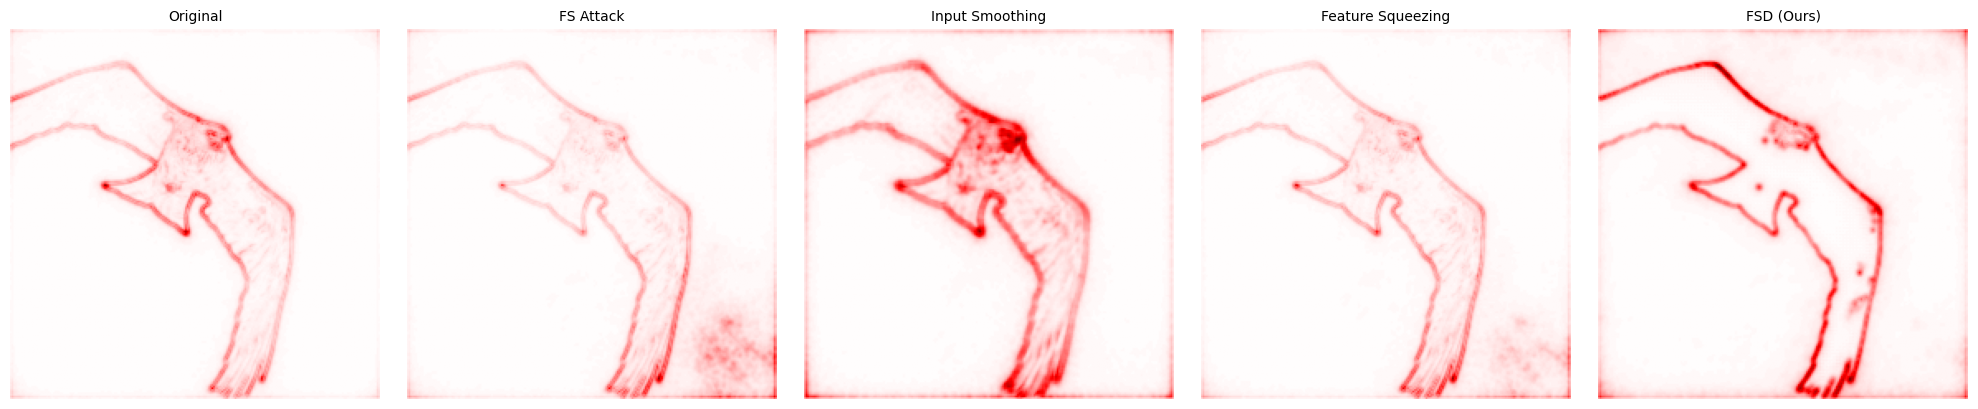

sota_comparison.png saved


In [ ]:
# ============================================================
# R1 Q3 — SOTA Comparison: 4 methods on single ImageNet image
# FS Attack vs Input Smoothing vs Feature Squeezing vs FSD
# ============================================================

exp_method_sota = 'lrp'
method_sota     = getattr(ExplainingMethod, exp_method_sota)

# Re-load image 11 cleanly
img_path_sota = 'tmp_image/11.jpeg'
x_sota = load_image(data_mean, data_std, device, img_path_sota)

# Original explanation
org_expl_sota, org_acc_sota, org_idx_sota = get_expl(
    model, x_sota, method_sota)
org_expl_sota     = org_expl_sota.detach()
org_expl_sota_cpu = org_expl_sota.cpu()
pred_class_sota   = model(x_sota).argmax(1).item()
print(f"Image 11 — pred_class={pred_class_sota}, "
      f"Gini_orig={gini_score(org_expl_sota):.4f}")

# FS Attack
x_adv_sota = x_sota.clone().detach().requires_grad_(True)
target_mtx_sota = get_center_attack_matrix(
    200, 200, 35, org_expl_sota, 224)
target_mtx_torch_sota = torch.tensor(
    target_mtx_sota).view(1,224,224).to(device).float()
opt_sota = torch.optim.Adam([x_adv_sota], lr=0.0002)

for it in range(150):
    if beta_growth:
        model.change_beta(get_beta(it, 150))
    opt_sota.zero_grad()
    adv_expl_sota, adv_acc_sota, _ = get_expl(
        model, x_adv_sota, method_sota,
        desired_index=org_idx_sota)
    loss = 1e4 * F.mse_loss(
        adv_acc_sota[0][pred_class_sota],
        org_acc_sota[0][pred_class_sota].detach()) + \
           1e10 * F.mse_loss(
               adv_expl_sota, target_mtx_torch_sota)
    x_tmp_sota = x_adv_sota
    loss.backward()
    opt_sota.step()
    if model(x_adv_sota).argmax(1).item() != pred_class_sota:
        x_adv_sota = x_tmp_sota
        break
    x_adv_sota.data = clamp(
        x_adv_sota.data, data_mean, data_std)

adv_expl_sota, _, _ = get_expl(
    model, x_adv_sota, method_sota,
    desired_index=org_idx_sota)
adv_expl_sota = adv_expl_sota.detach()
print(f"FS Attack done — "
      f"Gini={gini_score(adv_expl_sota):.4f}")

# --- Method 1: Input Smoothing ---
x_smooth = input_smoothing(x_adv_sota, kernel_size=3)
x_smooth = x_smooth.clone().detach().requires_grad_(True)
smooth_expl, _, _ = get_expl(
    model, x_smooth, method_sota,
    desired_index=org_idx_sota)
smooth_expl = smooth_expl.detach()

# --- Method 2: Feature Squeezing ---
x_squeeze = feature_squeezing(x_adv_sota, bit_depth=4)
x_squeeze = x_squeeze.clone().detach().requires_grad_(True)
squeeze_expl, _, _ = get_expl(
    model, x_squeeze, method_sota,
    desired_index=org_idx_sota)
squeeze_expl = squeeze_expl.detach()

# --- Method 3: FSD ---
torch.cuda.empty_cache()
defense_sota  = get_fresh_defense(epsilon=0.2)
x_fsd_sota    = defense_sota.defend(x_adv_sota, k_ratio=4)
x_fsd_sota    = x_fsd_sota.clone().detach().requires_grad_(True)
fsd_expl_sota, _, _ = get_expl(
    model, x_fsd_sota, method_sota,
    desired_index=org_idx_sota)
fsd_expl_sota = fsd_expl_sota.detach()

# --- Compute all metrics ---
methods_sota = {
    'FS Attack'        : adv_expl_sota,
    'Input Smoothing'  : smooth_expl,
    'Feature Squeezing': squeeze_expl,
    'FSD (Ours)'       : fsd_expl_sota,
}

print("\n" + "="*65)
print(f"{'Method':<22} {'Gini':>8} {'Spearman':>10} {'Top-K':>8}")
print("="*65)
print(f"{'Original':<22} "
      f"{gini_score(org_expl_sota):>8.4f} "
      f"{'—':>10} {'—':>8}")

for name, expl in methods_sota.items():
    g = gini_score(expl)
    sp, _ = spearmanr(
        org_expl_sota_cpu.numpy().flatten(),
        expl.cpu().numpy().flatten())
    tk = topk_intersection(
        expl, org_expl_sota_cpu, 90
    ) / total_topk_pixels
    print(f"{name:<22} {g:>8.4f} {sp:>10.4f} {tk:>8.4f}")

print("="*65)

# --- Visualization: 5-panel comparison ---
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
panels = [
    (org_expl_sota,  'Original'),
    (adv_expl_sota,  'FS Attack'),
    (smooth_expl,    'Input Smoothing'),
    (squeeze_expl,   'Feature Squeezing'),
    (fsd_expl_sota,  'FSD (Ours)'),
]
for ax, (expl, title) in zip(axes, panels):
    e = expl.cpu().squeeze().detach().numpy()
    vmax = np.abs(e).max()
    ax.imshow(e, cmap='seismic',
              vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sota_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("sota_comparison.png saved")

In [ ]:
# Multi-image SOTA comparison — 5 images
sota_cases = ['11', '0', '3', '7', '12']
results_sota = []

for case in sota_cases:
    img_path = f'tmp_image/{case}.jpeg'
    print(f"\nProcessing image {case}...")

    torch.cuda.empty_cache()
    x_i = load_image(data_mean, data_std, device, img_path)

    org_expl_i, org_acc_i, org_idx_i = get_expl(
        model, x_i, method_sota)
    org_expl_i     = org_expl_i.detach()
    org_expl_i_cpu = org_expl_i.cpu()
    pred_class_i   = model(x_i).argmax(1).item()

    # FS Attack
    x_adv_i = x_i.clone().detach().requires_grad_(True)
    target_mtx_i = get_center_attack_matrix(
        200, 200, 35, org_expl_i, 224)
    target_mtx_torch_i = torch.tensor(
        target_mtx_i).view(1,224,224).to(device).float()
    opt_i = torch.optim.Adam([x_adv_i], lr=0.0002)

    for it in range(150):
        if beta_growth:
            model.change_beta(get_beta(it, 150))
        opt_i.zero_grad()
        adv_expl_i, adv_acc_i, _ = get_expl(
            model, x_adv_i, method_sota,
            desired_index=org_idx_i)
        loss = 1e4 * F.mse_loss(
            adv_acc_i[0][pred_class_i],
            org_acc_i[0][pred_class_i].detach()) + \
               1e10 * F.mse_loss(
                   adv_expl_i, target_mtx_torch_i)
        x_tmp_i = x_adv_i
        loss.backward()
        opt_i.step()
        if model(x_adv_i).argmax(1).item() != pred_class_i:
            x_adv_i = x_tmp_i
            break
        x_adv_i.data = clamp(
            x_adv_i.data, data_mean, data_std)

    adv_expl_i, _, _ = get_expl(
        model, x_adv_i, method_sota,
        desired_index=org_idx_i)
    adv_expl_i = adv_expl_i.detach()

    # 3 defenses
    x_smooth_i   = input_smoothing(
        x_adv_i, kernel_size=3
    ).clone().detach().requires_grad_(True)
    x_squeeze_i  = feature_squeezing(
        x_adv_i, bit_depth=4
    ).clone().detach().requires_grad_(True)
    defense_i    = get_fresh_defense(epsilon=0.2)
    x_fsd_i      = defense_i.defend(
        x_adv_i, k_ratio=4
    ).clone().detach().requires_grad_(True)

    expls = {}
    for tag, x_in in [('adv',    x_adv_i),
                       ('smooth', x_smooth_i),
                       ('squeeze',x_squeeze_i),
                       ('fsd',    x_fsd_i)]:
        e, _, _ = get_expl(model, x_in, method_sota,
                           desired_index=org_idx_i)
        expls[tag] = e.detach()

    row = {'image': case}
    for tag, expl in expls.items():
        g  = gini_score(expl)
        sp, _ = spearmanr(
            org_expl_i_cpu.numpy().flatten(),
            expl.cpu().numpy().flatten())
        tk = topk_intersection(
            expl, org_expl_i_cpu, 90
        ) / total_topk_pixels
        row[f'gini_{tag}']  = round(g,  4)
        row[f'sp_{tag}']    = round(sp, 4)
        row[f'tk_{tag}']    = round(tk, 4)

    print(f"  Gini — adv={row['gini_adv']:.4f}, "
          f"smooth={row['gini_smooth']:.4f}, "
          f"squeeze={row['gini_squeeze']:.4f}, "
          f"fsd={row['gini_fsd']:.4f}")
    results_sota.append(row)
    torch.cuda.empty_cache()

# Summary
df_sota = pd.DataFrame(results_sota)
print("\n" + "="*70)
print("SOTA COMPARISON — Mean ± Std (5 images, LRP)")
print("="*70)
for metric in ['gini', 'sp', 'tk']:
    print(f"\n{metric.upper()}:")
    for tag in ['adv','smooth','squeeze','fsd']:
        col = f'{metric}_{tag}'
        print(f"  {tag:<10}: "
              f"{df_sota[col].mean():.4f} "
              f"± {df_sota[col].std():.4f}")


Processing image 11...
  Gini — adv=0.6925, smooth=0.7084, squeeze=0.6778, fsd=0.6898

Processing image 0...
  Gini — adv=0.5324, smooth=0.5722, squeeze=0.5003, fsd=0.5338

Processing image 3...
  Gini — adv=0.5108, smooth=0.3935, squeeze=0.4634, fsd=0.5729

Processing image 7...
  Gini — adv=0.4426, smooth=0.4393, squeeze=0.4456, fsd=0.5411

Processing image 12...
  Gini — adv=0.6099, smooth=0.5378, squeeze=0.5478, fsd=0.6272

SOTA COMPARISON — Mean ± Std (5 images, LRP)

GINI:
  adv       : 0.5576 ± 0.0962
  smooth    : 0.5302 ± 0.1230
  squeeze   : 0.5270 ± 0.0929
  fsd       : 0.5930 ± 0.0655

SP:
  adv       : 0.6486 ± 0.1865
  smooth    : 0.9467 ± 0.0186
  squeeze   : 0.7100 ± 0.1882
  fsd       : 0.7098 ± 0.1418

TK:
  adv       : 0.4323 ± 0.2887
  smooth    : 0.8046 ± 0.0651
  squeeze   : 0.5155 ± 0.3105
  fsd       : 0.5918 ± 0.1517


Imagenet Scale extended evaluation

In [ ]:
# Check which images are grayscale
from PIL import Image
import os

for case in ['29', '45']:
    img_path = f'tmp_image/{case}.jpeg'
    img = Image.open(img_path)
    print(f"image {case}: mode={img.mode}, "
          f"size={img.size}")

image 29: mode=L, size=(350, 156)
image 45: mode=L, size=(500, 375)


In [ ]:
import os
import shutil
from PIL import Image

imagenet_sample = '/content/drive/MyDrive/Dataset-exp[Imagenet]/Imagenet_sample'
tmp_image_path  = '/content/drive/MyDrive/FS_Attack-main/tmp_image'

# Find next available RGB images from imagenet_sample
# that are NOT already copied (skip first 36 already used)
all_files = sorted(os.listdir(imagenet_sample))
already_used = all_files[::27][:36]  # the 36 we copied earlier

replacements = []
for fname in all_files:
    if fname in already_used:
        continue
    img = Image.open(os.path.join(imagenet_sample, fname))
    if img.mode == 'RGB':
        replacements.append(fname)
    if len(replacements) == 2:
        break

print(f"Replacement images found:")
for i, fname in enumerate(replacements):
    img = Image.open(os.path.join(imagenet_sample, fname))
    print(f"  {fname} — mode={img.mode}, size={img.size}")

# Replace images 29 and 45
for case, fname in zip(['29', '45'], replacements):
    src = os.path.join(imagenet_sample, fname)
    dst = os.path.join(tmp_image_path, f'{case}.jpeg')
    shutil.copy2(src, dst)
    # Verify
    img = Image.open(dst)
    print(f"  Replaced image {case} → {fname} "
          f"mode={img.mode}")

print("\nVerifying all 50 images are RGB:")
failed = []
for i in range(50):
    img = Image.open(f'{tmp_image_path}/{i}.jpeg')
    if img.mode != 'RGB':
        failed.append(i)
if failed:
    print(f"Still grayscale: {failed}")
else:
    print("All 50 images confirmed RGB ✅")

Replacement images found:
  n01443537_goldfish.JPEG — mode=RGB, size=(376, 263)
  n01484850_great_white_shark.JPEG — mode=RGB, size=(500, 333)
  Replaced image 29 → n01443537_goldfish.JPEG mode=RGB
  Replaced image 45 → n01484850_great_white_shark.JPEG mode=RGB

Verifying all 50 images are RGB:
All 50 images confirmed RGB ✅


In [ ]:
# ============================================================
# Re-run only images 29 and 45 — merge into existing results
# ============================================================

import json
from torchvision.models import ResNet50_Weights

# Load existing checkpoint (48 images)
with open(CKPT_PATH, 'r') as f:
    results_50 = json.load(f)
done_cases = {r['image'] for r in results_50}
print(f"Existing checkpoint: {len(results_50)} images")
print(f"Running missing: 29, 45")

missing_cases = ['29', '45']
method_50 = getattr(ExplainingMethod, 'lrp')

for case in missing_cases:
    img_path = f'tmp_image/{case}.jpeg'
    print(f"\nProcessing image {case}...")

    try:
        torch.cuda.empty_cache()
        x_i = load_image(data_mean, data_std, device, img_path)

        # Original explanation
        org_expl_i, org_acc_i, org_idx_i = get_expl(
            model, x_i, method_50)
        org_expl_i_gpu = org_expl_i.detach()
        org_expl_i_cpu = org_expl_i_gpu.cpu()
        pred_class_i   = model(x_i).argmax(1).item()
        gini_orig_i    = gini_score(org_expl_i_gpu)
        print(f"  orig   Gini={gini_orig_i:.4f}, "
              f"pred={pred_class_i}")

        # FS Attack
        x_adv_i = x_i.clone().detach().requires_grad_(True)
        target_mtx_i = get_center_attack_matrix(
            200, 200, 35, org_expl_i_gpu, 224)
        target_mtx_torch_i = torch.tensor(
            target_mtx_i).view(1,224,224).to(device).float()
        opt_i = torch.optim.Adam([x_adv_i], lr=0.0002)

        for it in range(150):
            if beta_growth:
                model.change_beta(get_beta(it, 150))
            opt_i.zero_grad()
            adv_expl_i, adv_acc_i, _ = get_expl(
                model, x_adv_i, method_50,
                desired_index=org_idx_i)
            loss = 1e4 * F.mse_loss(
                adv_acc_i[0][pred_class_i],
                org_acc_i[0][pred_class_i].detach()) + \
                   1e10 * F.mse_loss(
                       adv_expl_i, target_mtx_torch_i)
            x_tmp_i = x_adv_i
            loss.backward()
            opt_i.step()
            if model(x_adv_i).argmax(1).item() != pred_class_i:
                x_adv_i = x_tmp_i
                break
            x_adv_i.data = clamp(
                x_adv_i.data, data_mean, data_std)

        adv_expl_i, _, _ = get_expl(
            model, x_adv_i, method_50,
            desired_index=org_idx_i)
        adv_expl_i  = adv_expl_i.detach()
        gini_adv_i  = gini_score(adv_expl_i)
        print(f"  attack Gini={gini_adv_i:.4f}")

        # FSD Defense
        torch.cuda.empty_cache()
        defense_i  = get_fresh_defense(epsilon=0.2)
        x_def_i    = defense_i.defend(x_adv_i, k_ratio=4)
        x_def_i    = x_def_i.clone().detach().requires_grad_(True)
        def_expl_i, _, _ = get_expl(
            model, x_def_i, method_50,
            desired_index=org_idx_i)
        def_expl_i  = def_expl_i.detach()
        gini_def_i  = gini_score(def_expl_i)
        print(f"  defense Gini={gini_def_i:.4f}")

        # Metrics
        sp_adv_i, _ = spearmanr(
            org_expl_i_cpu.numpy().flatten(),
            adv_expl_i.cpu().numpy().flatten())
        sp_def_i, _ = spearmanr(
            org_expl_i_cpu.numpy().flatten(),
            def_expl_i.cpu().numpy().flatten())
        tk_adv_i = topk_intersection(
            adv_expl_i, org_expl_i_cpu, 90
        ) / total_topk_pixels
        tk_def_i = topk_intersection(
            def_expl_i, org_expl_i_cpu, 90
        ) / total_topk_pixels

        print(f"  Spearman: adv={sp_adv_i:.4f}, "
              f"def={sp_def_i:.4f}")
        print(f"  Top-K:    adv={tk_adv_i:.4f}, "
              f"def={tk_def_i:.4f}")

        results_50.append({
            'image'     : case,
            'gini_orig' : round(gini_orig_i, 4),
            'gini_adv'  : round(gini_adv_i,  4),
            'gini_def'  : round(gini_def_i,  4),
            'sp_adv'    : round(sp_adv_i,    4),
            'sp_def'    : round(sp_def_i,    4),
            'tk_adv'    : round(tk_adv_i,    4),
            'tk_def'    : round(tk_def_i,    4)
        })

        # Save updated checkpoint
        with open(CKPT_PATH, 'w') as f:
            json.dump(results_50, f, indent=2)
        print(f"  checkpoint saved ({len(results_50)}/50)")

    except Exception as e:
        print(f"  [SKIP] Error: {e}")
        torch.cuda.empty_cache()

# Final summary — all 50
df_50 = pd.DataFrame(results_50)
print(f"\nTotal images: {len(df_50)}")
print("\n--- Final Mean ± Std (50 images) ---")
for col in ['gini_orig','gini_adv','gini_def',
            'sp_adv','sp_def','tk_adv','tk_def']:
    print(f"{col:12s}: "
          f"{df_50[col].mean():.4f} "
          f"± {df_50[col].std():.4f}")

# Gini improvement stats
improved = (df_50['gini_def'] > df_50['gini_adv']).sum()
exceeded = (df_50['gini_def'] > df_50['gini_orig']).sum()
print(f"\nGini improved (def>adv)   : "
      f"{improved}/50 ({100*improved/50:.1f}%)")
print(f"Gini exceeds original      : "
      f"{exceeded}/50 ({100*exceeded/50:.1f}%)")

Existing checkpoint: 48 images
Running missing: 29, 45

Processing image 29...
  orig   Gini=0.5555, pred=1
  attack Gini=0.7150
  defense Gini=0.6565
  Spearman: adv=0.3159, def=0.7843
  Top-K:    adv=0.2201, def=0.6127
  checkpoint saved (49/50)

Processing image 45...
  orig   Gini=0.4470, pred=2
  attack Gini=0.5257
  defense Gini=0.5942
  Spearman: adv=0.7264, def=0.5182
  Top-K:    adv=0.3614, def=0.4630
  checkpoint saved (50/50)

Total images: 50

--- Final Mean ± Std (50 images) ---
gini_orig   : 0.4973 ± 0.0921
gini_adv    : 0.5471 ± 0.0998
gini_def    : 0.5648 ± 0.0777
sp_adv      : 0.7591 ± 0.2001
sp_def      : 0.6297 ± 0.1552
tk_adv      : 0.4958 ± 0.2850
tk_def      : 0.4903 ± 0.1166

Gini improved (def>adv)   : 32/50 (64.0%)
Gini exceeds original      : 41/50 (82.0%)
